<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
LightGBM for Regression 
</p>

In [1]:
# Imports - core utils, data wrangling, ML, optimization, and plotting

# Standard library
import os
import pickle
import time
import warnings

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# ML and evaluation
import lightgbm as lgb
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
)
from sklearn.model_selection import PredefinedSplit, learning_curve

# Bayesian optimization
from skopt import BayesSearchCV
from skopt.space import Integer, Real

# Suppress known compatibility/noise warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*'force_all_finite'.*")
warnings.filterwarnings("ignore", category=UserWarning, module="skopt")
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils._tags")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Dataset: Load Splits 
</p>

In [ ]:
# Paths
TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV  = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"

MODELS_DIR     = "Models"
FIGURES_DIR    = "Figures"
CV_RESULTS_DIR = "CV_Results"
RESIDUALS_DIR  = "Residuals"

for directory in [MODELS_DIR, FIGURES_DIR, CV_RESULTS_DIR, RESIDUALS_DIR]:
    os.makedirs(directory, exist_ok=True)

CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "lgb_bayes_cv_results.csv")
MODEL_PATH      = os.path.join(MODELS_DIR, "lgbm_final_model.pkl")

# Load time-aware train/test split and predefined train folds
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)

# Optional datetime parsing for reporting/saving
for df in [df_train, df_test]:
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Feature/target setup
feature_names = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr"
]
target_col = "PL"

required_cols = [target_col, "device_id", *feature_names]
missing_train = [c for c in required_cols if c not in df_train.columns]
missing_test  = [c for c in required_cols if c not in df_test.columns]

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test}"
    )

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"fold_assignments length ({len(fold_assignments)}) does not match "
        f"df_train length ({len(df_train)})"
    )

# Train/test matrices
X_train_df = df_train[feature_names].copy()
X_test_df  = df_test[feature_names].copy()

X_train = X_train_df.to_numpy()
y_train = df_train[target_col].astype(float).to_numpy()

X_test = X_test_df.to_numpy()
y_test = df_test[target_col].astype(float).to_numpy()

print(f"Training samples: {len(df_train)}, Test samples: {len(df_test)}")
if "time" in df_train.columns and "time" in df_test.columns:
    print(f"Train window: {df_train.time.min()} -> {df_train.time.max()}")
    print(f"Test window:  {df_test.time.min()} -> {df_test.time.max()}")

unique, counts = np.unique(fold_assignments, return_counts=True)
print("Fold sizes:", dict(zip(unique.astype(int), counts.astype(int))))

Training samples: 1663627, Test samples: 415907
Train window: 2024-10-01 00:01:07.420593+00:00 -> 2025-08-12 17:18:53.293125+00:00
Test window:  2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00
Fold sizes: {0: 554543, 1: 277271, 2: 277271, 3: 277271, 4: 277271}


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Define Bayesian Search Space and Model Helper
</p>

In [3]:
# Our param space for Bayesian optimization
search_spaces = {
    'num_leaves': Integer(10, 100),  # Number of leaves in each tree (widened for flexibility)
    'max_depth': Integer(1, 14),      # Maximum tree depth
    'learning_rate': Real(0.03, 0.08, prior='log-uniform'),  # Learning rate
    'n_estimators': Integer(100, 300),  # Number of boosting iterations
    'min_child_samples': Integer(100, 1000),  # Minimum samples per leaf (similar to min_child_weight, but sample count)
    'min_child_weight': Real(5, 30, prior='log-uniform'),  # Minimum sum of instance weight (hessian)
    'subsample': Real(0.6, 0.8),     # Subsample ratio of training instances
    'colsample_bytree': Real(0.6, 0.8),  # Subsample ratio of columns
    'reg_alpha': Real(0, 10),         # L1 regularization
    'reg_lambda': Real(0, 10)         # L2 regularization
}

def create_lgb_model():
    return lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        random_state=50, 
        n_jobs=1,
        verbosity=-1  # Suppress LightGBM output
    )

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 Bayesian SearchCV with Custom Folds & Analysis Per-Depth Results 
</p>

In [4]:
# Bayesian SearchCV with predefined time-aware folds
scoring = {
    "neg_root_mean_squared_error": "neg_root_mean_squared_error",
    "r2": "r2",
}

ps = PredefinedSplit(fold_assignments)

bayes_cv = BayesSearchCV(
    estimator=create_lgb_model(),
    search_spaces=search_spaces,
    n_iter=30,
    scoring=scoring,
    refit="neg_root_mean_squared_error",
    n_jobs=8,
    cv=ps,
    random_state=42,
    verbose=1,
    n_points=2,
    optimizer_kwargs={"n_initial_points": 10, "acq_func": "gp_hedge"},
)

print(
    f"Starting Bayesian optimization with {bayes_cv.n_iter} iterations "
    f"and {ps.get_n_splits()} predefined folds...\n"
)

t0 = time.time()
bayes_cv.fit(X_train_df, y_train)
t1 = time.time()

print(f"\nBayesian optimization complete in {(t1 - t0)/60:.2f} minutes.")

bayes_results = pd.DataFrame(bayes_cv.cv_results_)
print(f"\nTried {bayes_results.shape[0]} configurations.")

bayes_results.to_csv(CV_RESULTS_PATH, index=False)
print(f"\nSaved BayesSearchCV cv_results_ to: {CV_RESULTS_PATH}")

Starting Bayesian optimization with 30 iterations and 5 predefined folds...

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Bayesian optimization 

In [5]:
# Load saved CV-search results and derive the best parameters
legacy_cv_results_path = os.path.join("LightGBM", "Results", "lgb_bayes_cv_results.csv")

if os.path.exists(CV_RESULTS_PATH):
    bayes_results = pd.read_csv(CV_RESULTS_PATH)
elif os.path.exists(legacy_cv_results_path):
    bayes_results = pd.read_csv(legacy_cv_results_path)
    bayes_results.to_csv(CV_RESULTS_PATH, index=False)
    print(f"Migrated legacy CV results to: {CV_RESULTS_PATH}")
else:
    raise FileNotFoundError(
        f"No CV results found. Run the BayesSearchCV cell or provide {CV_RESULTS_PATH}."
    )

if bayes_results.empty:
    raise ValueError("Loaded CV results are empty.")

if "mean_test_neg_root_mean_squared_error" not in bayes_results.columns:
    raise KeyError("Missing mean_test_neg_root_mean_squared_error in CV results.")

# Best overall configuration by validation RMSE
best_idx = bayes_results["mean_test_neg_root_mean_squared_error"].idxmax()
best_row = bayes_results.loc[best_idx]

param_cols = [c for c in bayes_results.columns if c.startswith("param_")]
int_params = {"num_leaves", "max_depth", "n_estimators", "min_child_samples"}

best_params = {}
for col in param_cols:
    name = col.replace("param_", "")
    value = best_row[col]
    if pd.isna(value):
        continue

    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        numeric_value = value

    if name in int_params:
        value = int(round(float(numeric_value)))
    elif isinstance(numeric_value, (int, float, np.integer, np.floating)):
        value = float(numeric_value)
    else:
        value = numeric_value

    best_params[name] = value

best_cv_rmse = -float(best_row["mean_test_neg_root_mean_squared_error"])
best_cv_r2 = float(best_row["mean_test_r2"]) if "mean_test_r2" in bayes_results.columns else np.nan

print("Best Parameters Found:", best_params)
print(f"Best CV RMSE: {best_cv_rmse:.4f}")
print(f"Best CV R2:   {best_cv_r2:.4f}")

# Best-per-depth summary for plotting
if "param_max_depth" not in bayes_results.columns:
    raise KeyError("Missing 'param_max_depth' in bayes_results. Did your search space include max_depth?")

bayes_results["param_max_depth"] = pd.to_numeric(bayes_results["param_max_depth"], errors="coerce")
plot_param_cols = [c.split("param_")[1] for c in bayes_results.columns if c.startswith("param_")]

rows = []
for depth in sorted(bayes_results["param_max_depth"].dropna().unique()):
    df_depth = bayes_results[bayes_results["param_max_depth"] == depth]
    idx = df_depth["mean_test_neg_root_mean_squared_error"].idxmax()
    row = df_depth.loc[idx]

    summary_row = {
        "max_depth": depth,
        "best_cv_rmse": -row["mean_test_neg_root_mean_squared_error"],
        "std_cv_rmse": row["std_test_neg_root_mean_squared_error"],
        "best_cv_r2": row["mean_test_r2"],
        "std_cv_r2": row["std_test_r2"],
    }

    for param in plot_param_cols:
        summary_row[param] = row[f"param_{param}"]

    rows.append(summary_row)

cv_df = pd.DataFrame(rows).sort_values("max_depth")

tbl = cv_df.copy()
num_cols = tbl.select_dtypes(include="number").columns
tbl[num_cols] = tbl[num_cols].round(4)

tbl_t = tbl.set_index("max_depth").T
tbl_t.index.name = "metric/param"
tbl_t.columns = [f"max_depth={int(c)}" for c in tbl_t.columns]
display(tbl_t)


Best Parameters Found: {'colsample_bytree': 0.7467494840181349, 'learning_rate': 0.0799999999999999, 'max_depth': 14, 'min_child_samples': 1000, 'min_child_weight': 30.0, 'n_estimators': 100, 'num_leaves': 10, 'reg_alpha': 10.0, 'reg_lambda': 2.863132328032973, 'subsample': 0.6}
Best CV RMSE: 5.7860
Best CV R2:   0.9038


,max_depth=1,max_depth=2,max_depth=3,max_depth=4,max_depth=5,max_depth=6,max_depth=7,max_depth=8,max_depth=9,max_depth=10,max_depth=11,max_depth=12,max_depth=13,max_depth=14
metric/param,,,,,,,,,,,,,,
best_cv_rmse,6.9183,5.8168,5.7975,5.8537,5.8451,5.8616,5.8385,5.9166,5.8915,5.8703,5.8319,5.8553,5.8811,5.7860
std_cv_rmse,0.5820,0.5904,0.5511,0.4688,0.4025,0.3856,0.4050,0.3733,0.4089,0.3782,0.4063,0.3737,0.3870,0.4493
best_cv_r2,0.8629,0.9026,0.9033,0.9016,0.9019,0.9013,0.9020,0.8993,0.9000,0.9010,0.9023,0.9015,0.9005,0.9038
std_cv_r2,0.0227,0.0208,0.0200,0.0178,0.0170,0.0173,0.0175,0.0182,0.0191,0.0168,0.0173,0.0170,0.0184,0.0176
colsample_bytree,0.6029,0.6890,0.7177,0.7407,0.7675,0.6755,0.7173,0.7599,0.6683,0.6010,0.7260,0.7524,0.6820,0.7467
learning_rate,0.0781,0.0739,0.0742,0.0436,0.0713,0.0696,0.0536,0.0461,0.0682,0.0592,0.0794,0.0619,0.0613,0.0800
min_child_samples,292.0000,490.0000,536.0000,559.0000,956.0000,612.0000,776.0000,744.0000,124.0000,226.0000,450.0000,787.0000,384.0000,1000.0000
min_child_weight,15.4655,7.0021,5.4986,11.1050,23.5176,10.2481,9.2263,25.2525,28.1613,17.7677,14.8442,15.2235,16.6129,30.0000
n_estimators,100.0000,191.0000,100.0000,172.0000,112.0000,108.0000,100.0000,243.0000,189.0000,229.0000,128.0000,191.0000,183.0000,100.0000


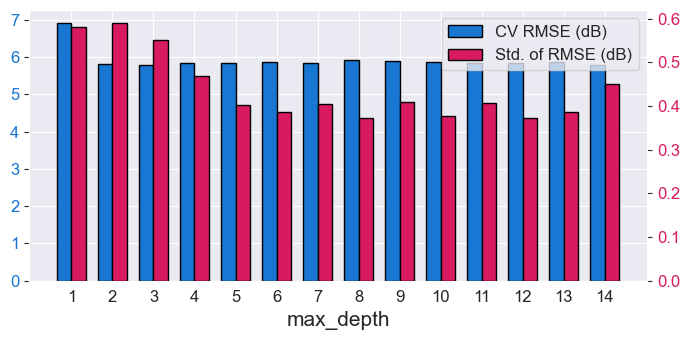

In [ ]:
# Plot best CV RMSE and standard deviation per max_depth

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("darkgrid")

x = np.arange(len(cv_df["max_depth"]))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_df["best_cv_rmse"],
    bar_width,
    color="#1976d2",
    label="RMSE",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)

ax1.set_xlabel("max_depth", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(v)}" for v in cv_df["max_depth"]], fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor="#1976d2", labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_df["std_cv_rmse"],
    bar_width,
    color="#d81b60",
    label="Std. of RMSE",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax2.tick_params(axis="y", labelcolor="#d81b60", labelsize=tick_fontsize)
ax2.grid(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color="#1976d2", ec="black", label="CV RMSE (dB)"),
    plt.Rectangle((0, 0), 1, 1, color="#d81b60", ec="black", label="Std. of RMSE (dB)"),
]
ax1.legend(handles=handles, loc="upper right", fontsize=legend_fontsize)

fig.tight_layout()
plt.show()

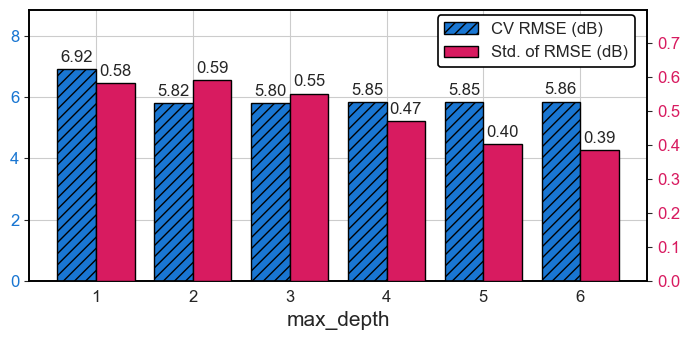

In [7]:
# Plot best CV RMSE and standard deviation for max_depth <= 6

tick_fontsize   = 12
axis_labelsize  = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

cv_df_plot = cv_df.copy()
cv_df_plot["max_depth"] = pd.to_numeric(cv_df_plot["max_depth"], errors="coerce")
cv_df_plot = cv_df_plot[cv_df_plot["max_depth"] <= 6].copy()
cv_df_plot = cv_df_plot.sort_values("max_depth").reset_index(drop=True)

x = np.arange(len(cv_df_plot["max_depth"]))
bar_width = 0.40

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_df_plot["best_cv_rmse"],
    bar_width,
    color="#1976d2",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
for bar in bars1:
    bar.set_hatch("///")

ax1.set_xlabel("max_depth", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(v)}" for v in cv_df_plot["max_depth"]], fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor="#1976d2", labelsize=tick_fontsize)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_df_plot["std_cv_rmse"],
    bar_width,
    color="#d81b60",
    edgecolor="black",
    linewidth=1,
    zorder=3,
)
ax2.tick_params(axis="y", labelcolor="#d81b60", labelsize=tick_fontsize)
ax2.grid(False)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=tick_fontsize)
ax2.bar_label(bars2, fmt="%.2f", padding=3, fontsize=tick_fontsize)

ax1.set_ylim(0, float(cv_df_plot["best_cv_rmse"].max()) * 1.28)
ax2.set_ylim(0, float(cv_df_plot["std_cv_rmse"].max()) * 1.35)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#1976d2", edgecolor="black", hatch="///", label="CV RMSE (dB)"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#d81b60", edgecolor="black", label="Std. of RMSE (dB)"),
]
leg = ax1.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    borderaxespad=0.0,
    fontsize=legend_fontsize,
    frameon=True,
    framealpha=1.0,
)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.2)
leg.get_frame().set_facecolor("white")

fig.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "LGBM_bestRMSE_STD_perDepth_first6.png")
plt.savefig(fig_path, dpi=2000, bbox_inches="tight", pad_inches=0.03)
plt.show()

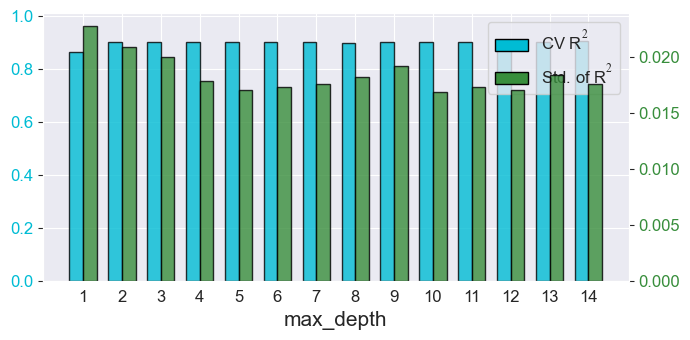

In [8]:
# Plot best CV R2 and standard deviation per max_depth

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("darkgrid")

x = np.arange(len(cv_df["max_depth"]))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars1 = ax1.bar(
    x - bar_width / 2,
    cv_df["best_cv_r2"],
    bar_width,
    color="#00bcd4",
    edgecolor="black",
    linewidth=1,
    alpha=0.8,
    label="R$^2$",
)
ax1.set_xlabel("max_depth", fontsize=axis_labelsize)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(v)}" for v in cv_df["max_depth"]], fontsize=tick_fontsize)
ax1.tick_params(axis="y", labelcolor="#00bcd4", labelsize=tick_fontsize)
ax1.tick_params(axis="x", labelsize=tick_fontsize)
ax1.set_ylim(0, 1.01)
ax1.grid(True, axis="y")

ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + bar_width / 2,
    cv_df["std_cv_r2"],
    bar_width,
    color="#388e3c",
    edgecolor="black",
    linewidth=1,
    alpha=0.8,
    label="Std. of R$^2$",
)
ax2.tick_params(axis="y", labelcolor="#388e3c", labelsize=tick_fontsize)
ax2.grid(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color="#00bcd4", ec="black", label="CV R$^2$"),
    plt.Rectangle((0, 0), 1, 1, color="#388e3c", ec="black", label="Std. of R$^2$"),
]
ax1.legend(handles=handles, loc="upper right", fontsize=legend_fontsize)

fig.tight_layout()
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 Train on All Training Data and Test Evaluation 
</p>

In [9]:
# Train final model, evaluate on held-out test, and save model/residual artifacts

best_model = create_lgb_model()
best_model.set_params(**best_params)
best_model.fit(X_train_df, y_train)

print("Best Parameters Used:", best_params)
print("\nFinal LightGBM model trained on the full training split.")

# Train/test predictions
y_train_pred = best_model.predict(X_train_df)
y_test_pred = best_model.predict(X_test_df)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_median_ae = median_absolute_error(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    "Metric": [
        "Train MSE", "Train RMSE", "Train R2",
        "Test MSE", "Test RMSE", "Test R2",
        "Test MAPE (%)", "Test Median AE",
    ],
    "Value": [
        train_mse, train_rmse, train_r2,
        test_mse, test_rmse, test_r2,
        test_mape * 100, test_median_ae,
    ],
})

print("\nModel Evaluation Metrics:")
display(metrics_df)

# Save final model
with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_model, f)
print(f"\nTrained LightGBM model saved to: {MODEL_PATH}")

# TEST residuals
PL_pred_test = y_test_pred
resid_test = y_test - PL_pred_test

lgb_test_df = pd.DataFrame({
    "model":       "LGBM",
    "split":       "test",
    "row_id":      np.arange(len(df_test), dtype=int),
    "time":        df_test.get("time", pd.Series(index=df_test.index, dtype=float)).values,
    "device_id":   df_test["device_id"].values,
    "distance":    df_test["distance"].values,
    "frequency":   df_test["frequency"].values,
    "c_walls":     df_test["c_walls"].values,
    "w_walls":     df_test["w_walls"].values,
    "co2":         df_test["co2"].values,
    "humidity":    df_test["humidity"].values,
    "pm25":        df_test["pm25"].values,
    "pressure":    df_test["pressure"].values,
    "temperature": df_test["temperature"].values,
    "snr":         df_test["snr"].values,
    "PL_true":     y_test,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test,
})

test_residual_path = os.path.join(RESIDUALS_DIR, "residuals_LGBM_test.csv")
lgb_test_df.to_csv(test_residual_path, index=False)
print(f"[TEST] Saved LightGBM test residuals: {test_residual_path}")

# OOF residuals using the selected best parameters
ps = PredefinedSplit(fold_assignments)
y_pred_oof = np.full(len(y_train), np.nan, dtype=float)

for fold_num in sorted(np.unique(fold_assignments)):
    tr_idx = np.where(fold_assignments != fold_num)[0]
    val_idx = np.where(fold_assignments == fold_num)[0]

    fold_model = create_lgb_model()
    fold_model.set_params(**best_params)
    fold_model.fit(X_train_df.iloc[tr_idx], y_train[tr_idx])
    y_pred_oof[val_idx] = fold_model.predict(X_train_df.iloc[val_idx])

mask = ~np.isnan(y_pred_oof)
PL_pred_oof = y_pred_oof[mask]
resid_oof = y_train[mask] - PL_pred_oof

lgb_oof_df = pd.DataFrame({
    "model":       "LGBM",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        df_train.get("time", pd.Series(index=df_train.index, dtype=float)).values[mask],
    "device_id":   df_train["device_id"].values[mask],
    "distance":    df_train["distance"].values[mask],
    "frequency":   df_train["frequency"].values[mask],
    "c_walls":     df_train["c_walls"].values[mask],
    "w_walls":     df_train["w_walls"].values[mask],
    "co2":         df_train["co2"].values[mask],
    "humidity":    df_train["humidity"].values[mask],
    "pm25":        df_train["pm25"].values[mask],
    "pressure":    df_train["pressure"].values[mask],
    "temperature": df_train["temperature"].values[mask],
    "snr":         df_train["snr"].values[mask],
    "PL_true":     y_train[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof,
})

oof_residual_path = os.path.join(RESIDUALS_DIR, "residuals_LGBM_oof.csv")
lgb_oof_df.to_csv(oof_residual_path, index=False)
print(f"[OOF] Saved LightGBM OOF residuals: {oof_residual_path}")

Best Parameters Used: {'colsample_bytree': 0.7467494840181349, 'learning_rate': 0.0799999999999999, 'max_depth': 14, 'min_child_samples': 1000, 'min_child_weight': 30.0, 'n_estimators': 100, 'num_leaves': 10, 'reg_alpha': 10.0, 'reg_lambda': 2.863132328032973, 'subsample': 0.6}

Final LightGBM model trained on the full training split.

Model Evaluation Metrics:


,Metric,Value
0,Train MSE,24.407656
1,Train RMSE,4.940411
2,Train R2,0.931058
3,Test MSE,24.180358
4,Test RMSE,4.917353
5,Test R2,0.931792
6,Test MAPE (%),4.243620
7,Test Median AE,2.906323



Trained LightGBM model saved to: Models/lgbm_final_model.pkl
[TEST] Saved LightGBM test residuals: Residuals/residuals_LGBM_test.csv
[OOF] Saved LightGBM OOF residuals: Residuals/residuals_LGBM_oof.csv


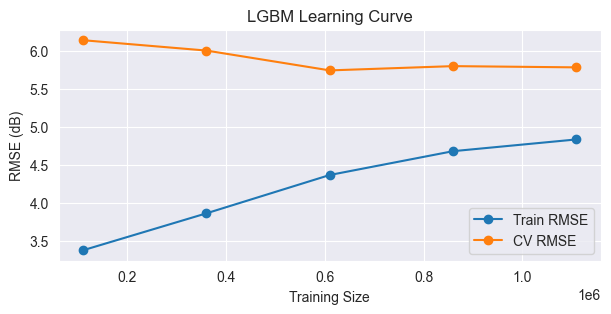

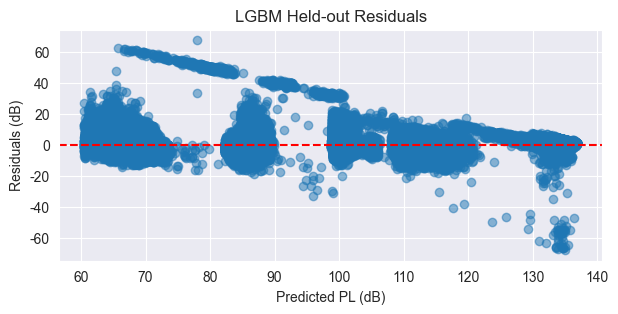

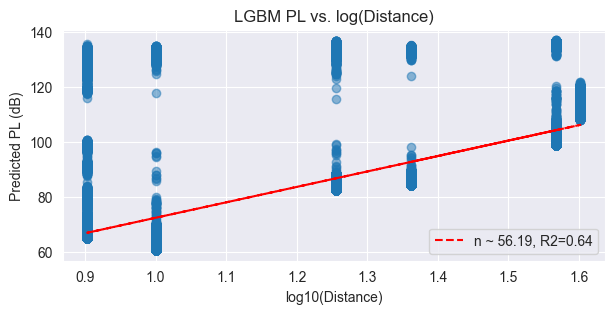

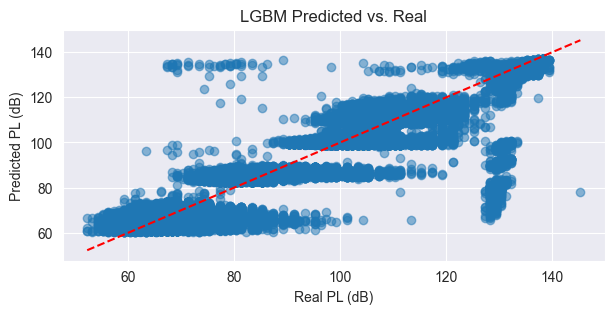

In [10]:
# Final LightGBM diagnostic plots

lgb_model = best_model
figsize = (7, 3)

# 1. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    lgb_model,
    X_train_df,
    y_train,
    cv=PredefinedSplit(fold_assignments),
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="neg_root_mean_squared_error",
)
train_rmse_curve = -train_scores.mean(axis=1)
val_rmse_curve = -test_scores.mean(axis=1)

plt.figure(figsize=figsize)
plt.plot(train_sizes, train_rmse_curve, "o-", label="Train RMSE")
plt.plot(train_sizes, val_rmse_curve, "o-", label="CV RMSE")
plt.xlabel("Training Size")
plt.ylabel("RMSE (dB)")
plt.title("LGBM Learning Curve")
plt.legend()
plt.show()


# 2. Held-out residuals
plt.figure(figsize=figsize)
plt.scatter(y_test_pred, resid_test, alpha=0.5)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted PL (dB)")
plt.ylabel("Residuals (dB)")
plt.title("LGBM Held-out Residuals")
plt.show()

# 3. Physics consistency: PL vs. log(distance)
dist = df_test["distance"].to_numpy()
log_dist = np.log10(dist + 1e-6)
slope, intercept, r_value, _, _ = linregress(log_dist, y_test_pred)

plt.figure(figsize=figsize)
plt.scatter(log_dist, y_test_pred, alpha=0.5)
plt.plot(log_dist, intercept + slope * log_dist, "r--", label=f"n ~ {slope:.2f}, R2={r_value**2:.2f}")
plt.xlabel("log10(Distance)")
plt.ylabel("Predicted PL (dB)")
plt.title("LGBM PL vs. log(Distance)")
plt.legend()
plt.show()


# 4. Predicted vs. real PL
plt.figure(figsize=figsize)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Real PL (dB)")
plt.ylabel("Predicted PL (dB)")
plt.title("LGBM Predicted vs. Real")
plt.show()